# 04 - LSTM Model
Bu notebook'ta zaman bağımlılıklarını modellemek için LSTM tabanlı derin öğrenme modeli geliştirilmektedir.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Veri Yükleme ve Ön İşleme

In [4]:
df = pd.read_csv("../data/raw/request_level_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Veri boyutu: {df.shape}")
df.head()

Veri boyutu: (29209, 14)


,request_id,timestamp,scenario,endpoint_name,endpoint_path,payload_size,response_time_ms,status_code,active_requests,rps_10s,requests_last_60s,client_send_ts,client_receive_ts,client_observed_latency_ms
0,3,2026-04-18 14:40:11.733971,low,users,/api/users,296,104.07,200,2,0.2,2,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.733971,112.62
1,1,2026-04-18 14:40:11.827719,low,users,/api/users,316,192.81,200,1,0.1,1,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.827719,213.20
2,2,2026-04-18 14:40:11.915110,low,search,/api/search,340,288.12,200,3,0.3,3,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.915110,293.71
3,6,2026-04-18 14:40:13.082376,low,users,/api/users,194,154.62,200,3,0.6,6,2026-04-18T14:40:12.915854,2026-04-18T14:40:13.082376,166.90
4,5,2026-04-18 14:40:13.254810,low,reports,/api/reports,387,314.19,200,2,0.5,5,2026-04-18T14:40:12.915854,2026-04-18T14:40:13.254810,339.68


## Feature Seçimi ve Ölçekleme

LSTM modeli için hem feature hem de target değişken ölçeklenmektedir. Bu, modelin daha hızlı ve stabil öğrenmesini sağlar.

In [5]:
features = ["payload_size", "active_requests", "rps_10s", "requests_last_60s"]
target = "response_time_ms"

# Feature scaler
scaler_X = MinMaxScaler()
scaled_features = scaler_X.fit_transform(df[features])

# Target scaler
scaler_y = MinMaxScaler()
scaled_target = scaler_y.fit_transform(df[[target]])

print("Feature shape:", scaled_features.shape)
print("Target shape:", scaled_target.shape)

Feature shape: (29209, 4)
Target shape: (29209, 1)


## Sliding Window - LSTM için 3D Veri Yapısı

LSTM modeli (samples, timesteps, features) formatında veri bekler. Önceki notebook'ta reshape ile düzleştirme yapılmıştı; burada 3D yapı korunmaktadır.

In [6]:
def create_window_3d(features_arr, target_arr, window_size):
    X, y = [], []
    for i in range(len(features_arr) - window_size):
        X.append(features_arr[i:i+window_size])
        y.append(target_arr[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10

X, y = create_window_3d(scaled_features, scaled_target, WINDOW_SIZE)

print(f"X shape: {X.shape}  →  (samples, timesteps, features)")
print(f"y shape: {y.shape}")

X shape: (29199, 10, 4)  →  (samples, timesteps, features)
y shape: (29199, 1)


## Train-Test Ayrımı

Zaman serisi verisi olduğundan shuffle yapılmadan kronolojik sırayla ayrım yapılmaktadır.

In [7]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (23359, 10, 4), Test: (5840, 10, 4)


## LSTM Model Mimarisi

İki katmanlı LSTM mimarisi kullanılmaktadır:
- **İlk LSTM katmanı**: 64 birim, return_sequences=True (ikinci katmana sekans çıktısı verir)
- **Dropout**: Overfitting'i önlemek için %20 dropout
- **İkinci LSTM katmanı**: 32 birim
- **Dense çıkış katmanı**: Tek bir regresyon çıktısı

In [8]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

C:\Users\bahar\source\repos\API-Analysis\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

## Model Eğitimi

EarlyStopping ile validation loss iyileşmediğinde eğitim otomatik durduruluyor. Bu hem overfitting'i önler hem de gereksiz eğitim süresini kısaltır.

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0047 - mae: 0.0485 - val_loss: 0.0043 - val_mae: 0.0481
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0043 - mae: 0.0465 - val_loss: 0.0042 - val_mae: 0.0444
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0041 - mae: 0.0454 - val_loss: 0.0039 - val_mae: 0.0452
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0040 - mae: 0.0444 - val_loss: 0.0038 - val_mae: 0.0434
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0039 - mae: 0.0435 - val_loss: 0.0038 - val_mae: 0.0416
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0039 - mae: 0.0429 - val_loss: 0.0037 - val_mae: 0.0425
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0038 - mae: 0.0425 - val_loss: 0.0036 - val_mae: 0.0413
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0038 - mae: 0.0422 - val_loss: 0.0037 - val_mae: 0.0414
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - lo

## Eğitim Grafiği

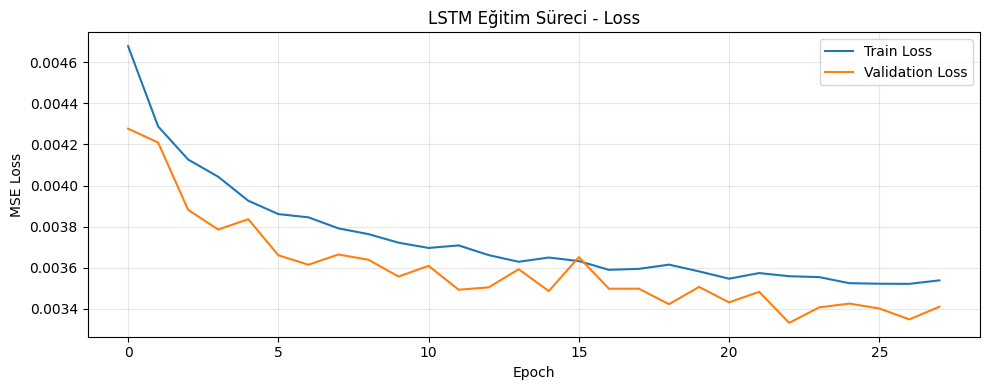

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Eğitim Süreci - Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tahmin ve Ters Ölçekleme

In [12]:
y_pred_scaled = model.predict(X_test)

# Ters ölçekleme - orijinal ms değerlerine dönüştür
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_orig = scaler_y.inverse_transform(y_test).flatten()

print(f"Tahmin örneği (ilk 5): {y_pred_lstm[:5].round(1)}")
print(f"Gerçek değer (ilk 5):  {y_test_orig[:5].round(1)}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Tahmin örneği (ilk 5): [305.5 365.5 353.7 379.8 351.9]
Gerçek değer (ilk 5):  [329.4 527.9 123.1 149.6 136.7]


## Performans Değerlendirmesi

In [13]:
def evaluate(y_true, y_pred, model_name):
    metrics = {
        "Model": model_name,
        "MAE": round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R2": round(r2_score(y_true, y_pred), 4)
    }
    return metrics

lstm_results = evaluate(y_test_orig, y_pred_lstm, "LSTM")
print(lstm_results)

{'Model': 'LSTM', 'MAE': 121.23, 'RMSE': np.float64(177.79), 'R2': 0.2008}


## Tüm Modellerin Karşılaştırması

In [14]:
#önceki notebook'ta elde edilen sonuçlar
lr_results  = {"Model": "Linear Regression", "MAE": 147.21, "RMSE": 196.44, "R2": 0.0242}
rf_results  = {"Model": "Random Forest",     "MAE": 146.37, "RMSE": 196.56, "R2": 0.0230}

comparison = pd.DataFrame([lr_results, rf_results, lstm_results])
comparison = comparison.set_index("Model")
print(comparison.to_string())
comparison

                      MAE    RMSE      R2
Model                                    
Linear Regression  147.21  196.44  0.0242
Random Forest      146.37  196.56  0.0230
LSTM               121.23  177.79  0.2008


,MAE,RMSE,R2
Model,,,
Linear Regression,147.21,196.44,0.0242
Random Forest,146.37,196.56,0.0230
LSTM,121.23,177.79,0.2008


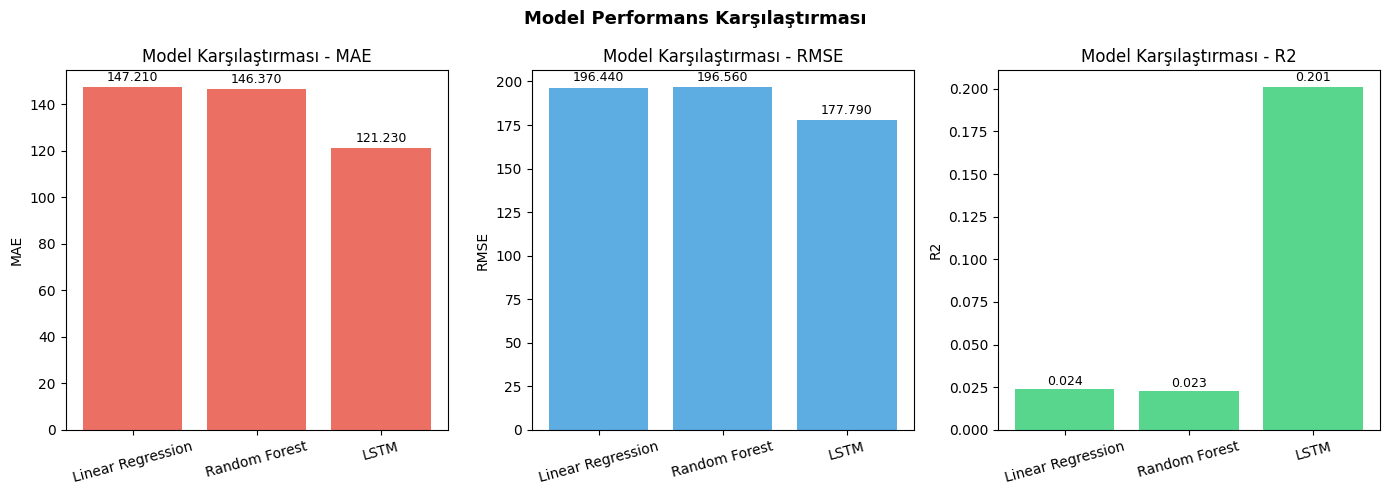

Grafik kaydedildi: ../outputs/model_comparison.png


In [15]:
#Karşılaştırma bar grafiği
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["MAE", "RMSE", "R2"]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

for ax, metric, color in zip(axes, metrics, colors):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(f"Model Karşılaştırması - {metric}")
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * bar.get_height(),
                f"{val:.3f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Model Performans Karşılaştırması", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: ../outputs/model_comparison.png")

## Gerçek vs Tahmin Grafiği (LSTM)

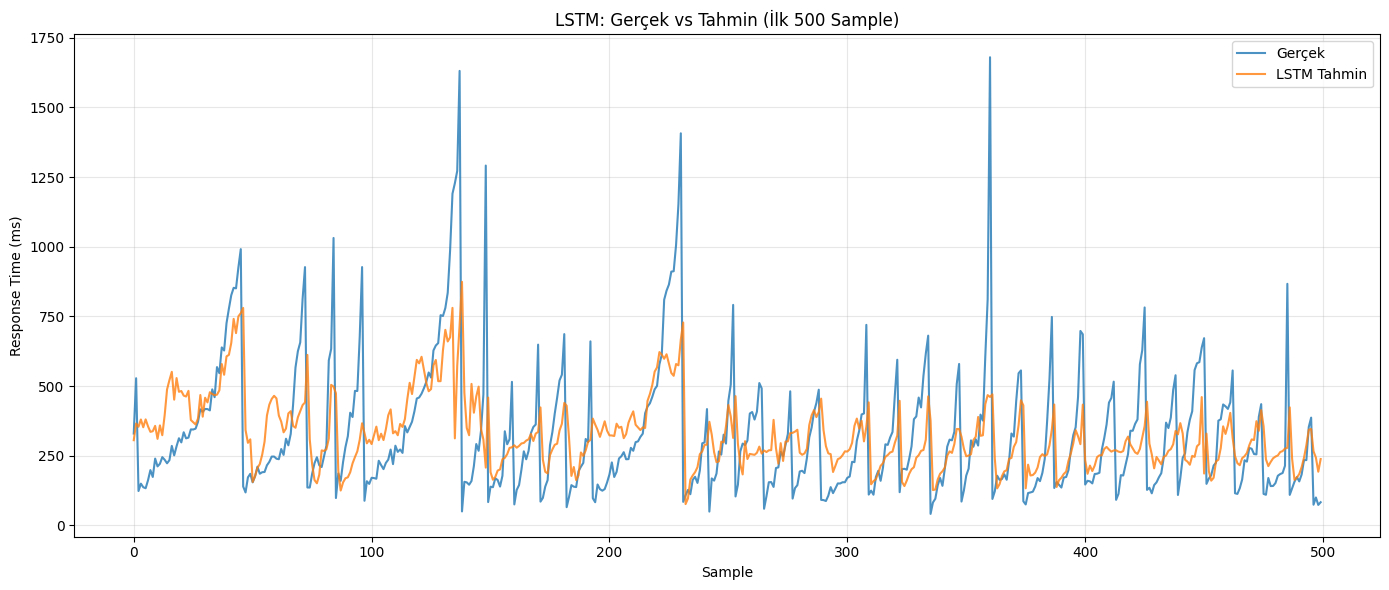

In [16]:
plt.figure(figsize=(14, 6))

n_plot = 500  # İlk 500 sample göster — daha okunabilir
plt.plot(y_test_orig[:n_plot], label="Gerçek", linewidth=1.5, alpha=0.8)
plt.plot(y_pred_lstm[:n_plot], label="LSTM Tahmin", linewidth=1.5, alpha=0.8)

plt.title("LSTM: Gerçek vs Tahmin (İlk 500 Sample)")
plt.xlabel("Sample")
plt.ylabel("Response Time (ms)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/lstm_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

## Model Kaydetme

In [17]:
models_path = "../models"
os.makedirs(models_path, exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# LSTM modelini kaydet
model.save(os.path.join(models_path, "lstm_model.keras"))

# Scaler'ları kaydet
joblib.dump(scaler_X, os.path.join(models_path, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(models_path, "scaler_y.pkl"))

# LSTM config
lstm_config = {
    "features": features,
    "target": target,
    "window_size": WINDOW_SIZE
}
joblib.dump(lstm_config, os.path.join(models_path, "lstm_config.pkl"))

# Tahmin sonuçlarını kaydet (04 notebook için)
results_df = pd.DataFrame({
    "y_true": y_test_orig,
    "y_pred_lstm": y_pred_lstm
})
results_df.to_csv("../data/lstm_test_results.csv", index=False)

print("Tüm dosyalar kaydedildi.")
print(f"  {models_path}/lstm_model.keras")
print(f"  {models_path}/scaler_X.pkl")
print(f"  {models_path}/scaler_y.pkl")
print(f"  {models_path}/lstm_config.pkl")
print(f"  ../data/lstm_test_results.csv")

Tüm dosyalar kaydedildi.
  ../models/lstm_model.keras
  ../models/scaler_X.pkl
  ../models/scaler_y.pkl
  ../models/lstm_config.pkl
  ../data/lstm_test_results.csv
